In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision
from torch.utils import data
from torchvision import transforms

In [2]:
## read data Fashion_MINST 
## 将pixel转换为float32
trans = transforms.ToTensor()

## torchvison加载数据
mnist_train = torchvision.datasets.FashionMNIST(
root="../data", train=True, transform=trans, download=True)

mnist_test = torchvision.datasets.FashionMNIST(
root="../data", train=False, transform=trans, download=True)

len(mnist_train)

## 灰度图 1*28*28




60000

In [3]:
## 根据数字labels返回text labels
def get_fashion_minst_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [4]:
def show_figure(imgs,num_rows,num_columns,titles=None,scale=1.5):
    ## 计算图片大小
    figsize = [num_columns*scale,num_rows*scale]
    _, axes = plt.subplots(
        num_rows,
        num_columns,
        figsize = figsize

    )
    axes = axes.flatten() ## 将图片展开为1维，便于遍历
    for i, (ax,img) in enumerate(zip(axes,imgs)): ## zip()将画布和图片zip合在一起，enumerate编号
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])

    return axes




array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

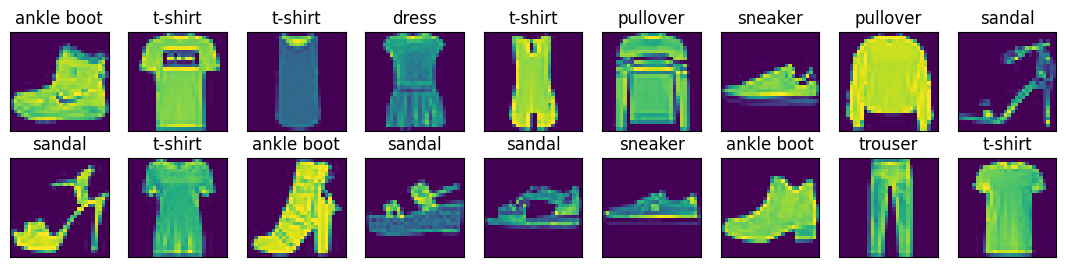

In [5]:
X,y = next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_figure(X.reshape(18,28,28),2,9,titles=get_fashion_minst_labels(y))

In [6]:
## 高效读取small batch size data
batch_size = 256
def get_data_loader_workers(): #@save
    ##4个进程读取数据
    return 4

train_iter = data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=get_data_loader_workers())


In [7]:
## 整理为一个完整的数据获取、读取函数
def load_data_fashion_minst(batch_size,resize = None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
    num_workers=get_data_loader_workers()),
    data.DataLoader(mnist_test, batch_size, shuffle=False,
    num_workers=get_data_loader_workers()))
        

In [8]:
train_iter, test_iter = load_data_fashion_minst(batch_size=256)

In [9]:
## 参数初始化
nums_input = 28*28
nums_output = 10
W = torch.normal(0,0.01,(nums_input,nums_output),requires_grad=True)
b = torch.zeros(nums_output,requires_grad=True)


In [10]:
## 手搓softmax
def softmax(X):
    ## 分子
    exp_X = torch.exp(X)
    ## 分母 将各个features求和，留下的是各个样本
    nominator = torch.exp(X).sum(1,keepdim=True)
    return exp_X/nominator

In [11]:
## define NN    
def net(X):
    return softmax(torch.matmul(X.reshape(-1,W.shape[0]),W) + b) ## 将X的column shape调整为与W的row shape一致

In [12]:
## cross entropy loss
def cross_entropy(y_hat,y):
    return - torch.log(y_hat[range(len(y_hat)),y]) ## y_hat可以看作是softmax的output probability matrix

In [13]:
## 计算 accuracy
def accuracy(y_hat,y):
    if len(y_hat.shape) >1 and y_hat.shape[1] >1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y ## 将预测结果和label一一比较
    return float(cmp.type(y.dtype).sum())   

In [14]:
## 定义一个累加器类，目的是计算不同batch间的正确预测数和总数的和
class Accumulator: #@save
    def __init__(self,n):
        self.data = [0.0]*n ## 维护data列表，data[0]为正确预测数，data[1]为总数
    
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

In [15]:
## 计算在指定data set下模型的精度
def evaluate_accuracy(data_iter,net):
    if isinstance(net,torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        metric.add(accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]




In [16]:
## trainning for one epoch
def train_epoch_softmax(net,train_iter,updater,loss):
    if isinstance(net,torch.nn.Module):
        net.train() ## tranning mode
    metric = Accumulator(3) ## 维护训练损失总和、训练准确度总和、样本数
    for X,y in train_iter:
        ## 计算梯度
        y_hat = net(X)
        l = loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer): ##如果updater属于torch内置优化器
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0]) ## 自定义优化器时，确定当前batch里有多少样本，求平均梯度
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())  
    return metric[0]/metric[2], metric[1]/metric[2]
    



In [17]:
def train_softmax(net, train_iter, test_iter, loss, updater, num_epochs):
    for epoch in range(num_epochs):

        train_loss, train_accuracy = train_epoch_softmax(
            net, train_iter, updater, loss
        )

        test_accuracy = evaluate_accuracy(
            test_iter,net
        )

        print(
            f'epoch {epoch + 1}, '
            f'train loss {train_loss:.3f}, '
            f'train acc {train_accuracy:.3f}, '
            f'test acc {test_accuracy:.3f}'
        )


In [18]:
def SGD(lr,batch_size,params):
    with torch.no_grad():
        for param in params:
            param -= (lr/batch_size)*param.grad
            param.grad.zero_()

In [19]:
lr = 0.1
num_epochs = 10

def updater(batch_size):
    return SGD(lr, batch_size, [W, b])

In [20]:
train_softmax(net,train_iter,test_iter,cross_entropy,updater,num_epochs)

/var/folders/yk/t4m8n8bs3rq4njwknlv5jmcr0000gn/T/ipykernel_87513/2022649830.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())


epoch 1, train loss 0.786, train acc 0.749, test acc 0.833
epoch 2, train loss 0.570, train acc 0.813, test acc 0.778
epoch 3, train loss 0.526, train acc 0.825, test acc 0.778
epoch 4, train loss 0.502, train acc 0.832, test acc 0.833
epoch 5, train loss 0.485, train acc 0.837, test acc 0.833
epoch 6, train loss 0.475, train acc 0.840, test acc 0.833
epoch 7, train loss 0.465, train acc 0.843, test acc 0.889
epoch 8, train loss 0.458, train acc 0.845, test acc 0.889
epoch 9, train loss 0.453, train acc 0.846, test acc 0.889
epoch 10, train loss 0.447, train acc 0.848, test acc 0.889


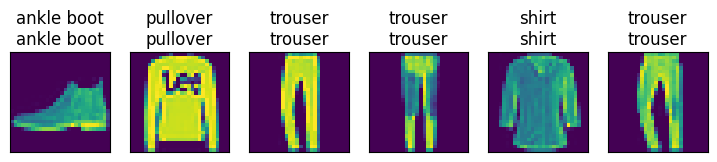

In [21]:
## 展示预测结果
def predict_softmax(net,test_iter,n=6):
    for X,y in test_iter: ## 就用第一个epoch拿出来看看
        break
    trues = get_fashion_minst_labels(y)
    predticts = get_fashion_minst_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, predticts)]
    show_figure(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n]
    )

predict_softmax(net,test_iter)